---
## 🎁 가산점 신청 (선택)

가산점을 받으려면 아래 항목 중 시도한 것을 **체크**하고, **해당 코드 셀 번호**를 적어주세요.
신청하지 않은 항목은 채점하지 않습니다.

### A. 알고리즘의 다양성 ⭐⭐-5번째 셀
- 모델 개발에 시도된 기계학습 알고리즘의 종류를 기준으로 판단

### B. Hyperparameter 탐색의 다양성 ⭐⭐-5번째 셀
- 각 기계학습 알고리즘에서 유의미한 하이퍼파라미터들을 최적화했는지 확인

### C. 모델 성능 평가 ⭐⭐-6번째 셀
- 모델 성능 평가에 사용된 지표의 다양성 (지수를 종합적으로 판단해서 최종 모델을 선택해야 함)

### D. 모델 개발 과정 시각화 및 설명 ⭐⭐-7,8,9,10번째 셀
- 실험 과정에 대한 시각화 (learning curve)
- 모델 성능에 대한 시각화
- 코드에 대한 설명



# 기말고사 Template 2 — Machine Learning Model Pipeline

**이름:** ______육건우______ &nbsp; **학번:** _______20251284_______ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 모델 저장 & 새 분자 예측** | 5점 | 모델을 저장한 후, 새로운 분자 구조를 예측할 수 있도록 정리. |

## 📁 입력 / 출력
- **입력**: Template 1에서 만든 `final_dataset_descriptors.csv`
- **출력**: 
  - `experiment_results.csv` — 모든 실험 결과 표
  - `experiment_best.csv` — 모델별 베스트만
  - `model_best.joblib` — 최고 모델 저장 파일 (features + scaler + model)

---

# 전체 통합 알고리즘, 종별, 성별 머신러닝 모델 파이프라인

* **주요 목표**: 생물학적 변수 조건에 따른 독립적 머신러닝 파이프라인 구축 및 정확도·독성학적 평가지표 극대화
* **사용 데이터**: `cancer_descriptors.csv` (RDKit Morgan Fingerprint 32비트 및 수치형 Descriptor 기반)
* **분석 전략 (5대 시나리오 독립 구동)**:
  1. **Total**: 전체 데이터를 통합하고 생물학적 변수를 독립 변수로 포함한 통합 Baseline 모델
  2. **Rat / Mouse**: 동물 종별 생물학적 메커니즘 차이를 반영한 독립 세부 모델
  3. **Male / Female**: 성별 호르몬 및 생리적 대사 차이를 반영한 독립 세부 모델

In [3]:
import pandas as pd
import numpy as np

# =====================================================================
# Step 1. 데이터 로드 및 서브셋(Subset) 분할
# =====================================================================
input_file_path = "cancer_descriptors.csv"
df_raw = pd.read_csv(input_file_path)

# 1.2 데이터 기본 정보 및 결측치 확인
print("데이터 전반적 특징 확인:")
print(f"- 독성 라벨 분포 (0: 비발암성, 1: 발암성):\n{df_raw['label'].value_counts(dropna=False)}")
print(f"- 동물 종 분포 (1: Rat, 0: Mouse):\n{df_raw['Is_Rat'].value_counts(dropna=False)}")
print(f"- 성별 분포 (1: Male, 0: Female):\n{df_raw['Is_Male'].value_counts(dropna=False)}\n")

데이터 전반적 특징 확인:
- 독성 라벨 분포 (0: 비발암성, 1: 발암성):
label
0    974
1    708
Name: count, dtype: int64
- 동물 종 분포 (1: Rat, 0: Mouse):
Is_Rat
0    847
1    835
Name: count, dtype: int64
- 성별 분포 (1: Male, 0: Female):
Is_Male
0    860
1    822
Name: count, dtype: int64



In [4]:
# 1.3 5가지 시나리오별 서브셋 분할 전략 적용
# 데이터를 독립적인 생물학적 조건(종, 성별)에 따라 5개의 딕셔너리 형태로 관리합니다.
datasets = {}

# Scenario 1: 전체 통합 데이터셋 (Total Dataset)
datasets['Total'] = df_raw.copy()

# Scenario 2: 쥐 전용 데이터셋 (Rat-only)
datasets['Rat'] = df_raw[df_raw['Is_Rat'] == 1].copy()

# Scenario 3: 생쥐 전용 데이터셋 (Mouse-only)
datasets['Mouse'] = df_raw[df_raw['Is_Rat'] == 0].copy()

# Scenario 4: 수컷 전용 데이터셋 (Male-only)
datasets['Male'] = df_raw[df_raw['Is_Male'] == 1].copy()

# Scenario 5: 암컷 전용 데이터셋 (Female-only)
datasets['Female'] = df_raw[df_raw['Is_Male'] == 0].copy()


# 1.4 서브셋 분할 결과 검증 및 요약 출력
print("======  5가지 시나리오별 서브셋 분할 요약 ======")
for name, df_sub in datasets.items():
    total_cnt = len(df_sub)
    pos_cnt = df_sub['label'].sum()
    neg_cnt = total_cnt - pos_cnt
    pos_ratio = (pos_cnt / total_cnt) * 100 if total_cnt > 0 else 0
    
    print(f"🔹 [{name:6s} 데이터셋] 총 샘플 수: {total_cnt:4d}개 | "
          f"발암성(1): {pos_cnt:3d}개 | 비발암성(0): {neg_cnt:3d}개 | "
          f"양성 비율: {pos_ratio:.1f}%")
print("==================================================")

======  5가지 시나리오별 서브셋 분할 요약 ======
🔹 [Total  데이터셋] 총 샘플 수: 1682개 | 발암성(1): 708개 | 비발암성(0): 974개 | 양성 비율: 42.1%
🔹 [Rat    데이터셋] 총 샘플 수:  835개 | 발암성(1): 352개 | 비발암성(0): 483개 | 양성 비율: 42.2%
🔹 [Mouse  데이터셋] 총 샘플 수:  847개 | 발암성(1): 356개 | 비발암성(0): 491개 | 양성 비율: 42.0%
🔹 [Male   데이터셋] 총 샘플 수:  822개 | 발암성(1): 358개 | 비발암성(0): 464개 | 양성 비율: 43.6%
🔹 [Female 데이터셋] 총 샘플 수:  860개 | 발암성(1): 350개 | 비발암성(0): 510개 | 양성 비율: 40.7%


## 시나리오별 가지고 있는 데이터의 수와 비율을 확인

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =====================================================================
# Step 2. 독립변수/종속변수 정의, 스케일링 및 Train/Test 분할
# =====================================================================

X_train_dict = {}
X_test_dict = {}
y_train_dict = {}
y_test_dict = {}

print("🔍 시나리오별 피처 엔지니어링 및 데이터 분할 시작...\n")

for name, df_sub in datasets.items():
    if df_sub.empty:
        print(f"⚠️ [{name}] 데이터셋이 비어있어 건너뜁니다.")
        continue
        
    # 2.1 종속변수(y) 분리
    y = df_sub['label'].values
    
    # 2.2 독립변수(X) 추출 시 불필요한 메타데이터 컬럼 제외
    drop_cols = ['SMILES', 'label']
    if name == 'Rat' or name == 'Mouse':
        drop_cols.append('Is_Rat')
    elif name == 'Male' or name == 'Female':
        drop_cols.append('Is_Male')
        
    X_raw = df_sub.drop(columns=[col for col in drop_cols if col in df_sub.columns])
    
    X_numeric = X_raw.select_dtypes(include=[np.number])
    
    # 2.3 피처 그룹 분리
    fp_cols = [col for col in X_numeric.columns if col.startswith('FP_')]
    desc_cols = [col for col in X_numeric.columns if col not in fp_cols]
    
    # 2.4 데이터 분할 (Train 80% / Test 20%)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_numeric, y, test_size=0.2, stratify=y
    )
    
    # 2.5 데이터 스케일링
    X_train_scaled = X_train_raw.copy()
    X_test_scaled = X_test_raw.copy()
    
    if len(desc_cols) > 0:
        scaler = StandardScaler()
        # Train 데이터로 피팅 및 변환
        X_train_scaled[desc_cols] = scaler.fit_transform(X_train_raw[desc_cols])
        # Test 데이터는 Train의 파라미터로 변환만 수행
        X_test_scaled[desc_cols] = scaler.transform(X_test_raw[desc_cols])
    
    # 최종 가공된 데이터를 딕셔너리에 저장
    X_train_dict[name] = X_train_scaled
    X_test_dict[name] = X_test_scaled
    y_train_dict[name] = y_train
    y_test_dict[name] = y_test
    
    # 2.6 분할 결과 출력
    print(f"📊 [{name:6s} 데이터셋 분할 완료]")
    print(f"   - Train 구조: {X_train_scaled.shape} | Test 구조: {X_test_scaled.shape}")
    print(f"   - 수치형 Descriptor 개수: {len(desc_cols)}개 | Fingerprint 개수: {len(fp_cols)}개")
    print(f"   - Train 양성률: {np.mean(y_train)*100:.1f}% | Test 양성률: {np.mean(y_test)*100:.1f}%\n")

🔍 시나리오별 피처 엔지니어링 및 데이터 분할 시작...

📊 [Total  데이터셋 분할 완료]
   - Train 구조: (1345, 38) | Test 구조: (337, 38)
   - 수치형 Descriptor 개수: 6개 | Fingerprint 개수: 32개
   - Train 양성률: 42.1% | Test 양성률: 42.1%

📊 [Rat    데이터셋 분할 완료]
   - Train 구조: (668, 37) | Test 구조: (167, 37)
   - 수치형 Descriptor 개수: 5개 | Fingerprint 개수: 32개
   - Train 양성률: 42.2% | Test 양성률: 41.9%

📊 [Mouse  데이터셋 분할 완료]
   - Train 구조: (677, 37) | Test 구조: (170, 37)
   - 수치형 Descriptor 개수: 5개 | Fingerprint 개수: 32개
   - Train 양성률: 42.1% | Test 양성률: 41.8%

📊 [Male   데이터셋 분할 완료]
   - Train 구조: (657, 37) | Test 구조: (165, 37)
   - 수치형 Descriptor 개수: 5개 | Fingerprint 개수: 32개
   - Train 양성률: 43.5% | Test 양성률: 43.6%

📊 [Female 데이터셋 분할 완료]
   - Train 구조: (688, 37) | Test 구조: (172, 37)
   - 수치형 Descriptor 개수: 5개 | Fingerprint 개수: 32개
   - Train 양성률: 40.7% | Test 양성률: 40.7%



## A. 알고리즘의 다양성: LogisticRegression, RandomForest, SVM
## B. Hyperparameter 탐색의 다양성
-모델의 과적합(Overfitting)을 원천 방지하기 위해 Train 데이터 내에서 `StratifiedKFold(5-Fold)` 교차 검증을 수행하였으며, `GridSearchCV`를 연계하여 각 알고리즘별 최적의 하이퍼파라미터 조합(`C`, `penalty`, `n_estimators`, `max_depth`, `gamma` 등)을 자동 탐색함.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import warnings

warnings.filterwarnings('ignore')

In [41]:
# =====================================================================
# Step 3. 다각적 머신러닝 모델 학습 및 하이퍼파라미터 최적화
# =====================================================================

# 3.1 하이퍼파라미터 탐색 그리드 정의
param_grids = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'probability': [True]
    }
}

# 3.2 모델 객체 생성- random_state 제거
model_templates = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(),
    'SVM': SVC()
}

# 최적화된 학습 모델들을 저장할 구조 정의
best_estimators = {}

print(" 5가지 시나리오 3종 머신러닝 알고리즘에 대한 GridSearchCV 최적화 시작...\n")

# 교차 검증을 위한 Stratified K-Fold (K=5) 설정 - random_state 제거 (매 실행마다 데이터 분할이 달라짐)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True)

for subset_name in datasets.keys():
    print(f" [{subset_name}] 데이터셋 기반 하이퍼파라미터 튜닝...")
    
    X_train = X_train_dict[subset_name]
    y_train = y_train_dict[subset_name]
    
    best_estimators[subset_name] = {}
    
    for model_name, model in model_templates.items():
        # 각 모델과 매칭되는 하이퍼파라미터 그리드 로드
        grid = param_grids[model_name]
        
        # 교차 검증 시 평가 지표는 발암성 데이터 분포를 종합 고려해 'roc_auc'를 기준으로 최적화
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=grid,
            cv=cv_strategy,
            scoring='roc_auc',
            n_jobs=-1 # 병렬 연산 속도 향상
        )
        
        # 모델 학습
        grid_search.fit(X_train, y_train)
        
        # 최적 모델 저장
        best_estimators[subset_name][model_name] = grid_search.best_estimator_
        
        print(f"   ↳ 🤖 {model_name:18s} 최적 Parameter: {grid_search.best_params_}")
        print(f"   ↳ ⭐ Best 5-Fold ROC-AUC: {grid_search.best_score_:.4f}")
    print("-" * 70)

 5가지 시나리오 3종 머신러닝 알고리즘에 대한 GridSearchCV 최적화 시작...

 [Total] 데이터셋 기반 하이퍼파라미터 튜닝...
   ↳ 🤖 LogisticRegression 최적 Parameter: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
   ↳ ⭐ Best 5-Fold ROC-AUC: 0.6358
   ↳ 🤖 RandomForest       최적 Parameter: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
   ↳ ⭐ Best 5-Fold ROC-AUC: 0.8380
   ↳ 🤖 SVM                최적 Parameter: {'C': 10, 'gamma': 'scale', 'probability': True}
   ↳ ⭐ Best 5-Fold ROC-AUC: 0.7706
----------------------------------------------------------------------
 [Rat] 데이터셋 기반 하이퍼파라미터 튜닝...
   ↳ 🤖 LogisticRegression 최적 Parameter: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
   ↳ ⭐ Best 5-Fold ROC-AUC: 0.6082
   ↳ 🤖 RandomForest       최적 Parameter: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
   ↳ ⭐ Best 5-Fold ROC-AUC: 0.7990
   ↳ 🤖 SVM                최적 Parameter: {'C': 10, 'gamma': 0.1, 'probability': True}
   ↳ ⭐ Best 5-Fold ROC-AUC: 0.7373
-------------------------------------------------

## 모델 성능 평가
- 모델 성능 평가에 사용된 지표의 다양성 (지수를 종합적으로 판단해서 최종 모델을 선택)

In [42]:
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# =====================================================================
# Step 4. 모델 성능 평가 및 결과 정리 (CSV 파일 출력)
# =====================================================================

# 결과를 저장할 리스트 초기화
results_list = []

print("📊 숨겨진 Test Set 기반 모델 성능 평가 및 스코어링 시작...\n")

for subset_name in datasets.keys():
    X_test = X_test_dict[subset_name]
    y_test = y_test_dict[subset_name]
    
    for model_name, model in best_estimators[subset_name].items():
        # 4.1 예측값 및 예측 확률 산출
        y_pred = model.predict(X_test)
        
        # SVM이나 로지스틱 회귀 등에서 확률 값을 가져옴 (ROC-AUC 계산용)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)
            
        # 4.2 다각적 평가지표 계산
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_prob)
        
        # 결과 데이터 저장
        results_list.append({
            'Subset': subset_name,
            'Model_Algorithm': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc
        })

# 4.3 데이터프레임 변환 및 정렬
df_results = pd.DataFrame(results_list)

# 4.4 모든 실험 결과 표 저장
output_file_all = 'experiment_results.csv'
df_results.to_csv(output_file_all, index=False, encoding='utf-8-sig')
print(f" [출력 완료] 모든 실험 결과가 '{output_file_all}'에 저장되었습니다.")

# 4.5 각 서브셋별 최적의 베스트 모델만 추출
# ROC_AUC 점수가 가장 높은 행을 기준으로 그룹화하여 추출합니다.
df_best = df_results.loc[df_results.groupby('Subset')['ROC_AUC'].idxmax()]
output_file_best = 'experiment_best.csv'
df_best.to_csv(output_file_best, index=False, encoding='utf-8-sig')
print(f" [출력 완료] 시나리오별 최고 성능 모델 요약이 '{output_file_best}'에 저장되었습니다.\n")


# 4.6 주피터 노트북 상에 깔끔한 시각적 표(Table)로 출력
print("================  [전체 모델 성능 비교 성적표]  ================")
print(df_results.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format,
    'Precision': '{:,.4f}'.format,
    'Recall': '{:,.4f}'.format,
    'F1_Score': '{:,.4f}'.format,
    'ROC_AUC': '{:,.4f}'.format
}))
print("===================================================================\n")

print("================  [시나리오별 BEST 모델 요약]  ================")
print(df_best.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format,
    'Precision': '{:,.4f}'.format,
    'Recall': '{:,.4f}'.format,
    'F1_Score': '{:,.4f}'.format,
    'ROC_AUC': '{:,.4f}'.format
}))
print("===================================================================")

📊 숨겨진 Test Set 기반 모델 성능 평가 및 스코어링 시작...

 [출력 완료] 모든 실험 결과가 'experiment_results.csv'에 저장되었습니다.
 [출력 완료] 시나리오별 최고 성능 모델 요약이 'experiment_best.csv'에 저장되었습니다.

================  [전체 모델 성능 비교 성적표]  ================
Subset    Model_Algorithm Accuracy Precision Recall F1_Score ROC_AUC
 Total LogisticRegression   0.5994    0.5522 0.2606   0.3541  0.6042
 Total       RandomForest   0.7834    0.7594 0.7113   0.7345  0.8467
 Total                SVM   0.7359    0.6853 0.6901   0.6877  0.7881
   Rat LogisticRegression   0.5868    0.5122 0.3000   0.3784  0.5694
   Rat       RandomForest   0.6826    0.6441 0.5429   0.5891  0.7378
   Rat                SVM   0.6407    0.5833 0.5000   0.5385  0.6411
 Mouse LogisticRegression   0.6706    0.6271 0.5211   0.5692  0.7115
 Mouse       RandomForest   0.8706    0.8451 0.8451   0.8451  0.8922
 Mouse                SVM   0.7941    0.7195 0.8310   0.7712  0.8621
  Male LogisticRegression   0.6121    0.6333 0.2639   0.3725  0.6314
  Male       RandomForest   0.6

## 모델 개발 과정 시각화 및 코드 설명
  - 시나리오별 최적 모델에 대한 Confusion Matrix 오차 분석 플롯을 시각화하여, 독성학적 관점에서 치명적인 오류인 **False Negative** 패턴을 정밀 진단하고 원인을 분석

### 1. 독성 예측에서 False Negative이 치명적인 이유
* **False Negative의 정의**: 실제로는 발암성 독성이 있는 물질(Positive, 1)인데, 머신러닝 모델이 안전한 물질(Negative, 0)이라고 잘못 예측한 오류.
* **리스크**: False Positive( - 실제 안전한데 독성이 있다고 예측) 오류는 단순히 유망한 후보 물질을 아깝게 버리는 비용적 손실에 그치지만, **False Negative는 발암성 물질을 '안전하다'고 판정하여 임상 시험이나 시판 단계로 통과시키는 문제**를 초래한다. 따라서 독성학 스크리닝 모델에서는 위음성을 줄여 **재현율(Recall, 민감도)을 극대화**하는 것이 핵심이다.

### 2. 모델이 독성을 놓치는(False Negative) 원인 분석

#### 💡 원인 ① : 데이터 불균형(Data Imbalance)의 한계 (데이터 과학 관점)
* **현상**: 일반적으로 독성 물질 데이터셋은 '독성 없음(Safe)' 데이터에 비해 '독성 있음(Toxic)' 데이터의 수가 훨씬 적은 비대칭 구조를 가진다.
* **원인**: Random Forest 알고리즘은 전체 정확도(Accuracy)를 높이는 방향으로 나무(Tree)들을 가지치기한다. 데이터의 다수를 차지하는 '안전군(0)'을 맞추는 것이 유리하다 보니, 상대적으로 데이터 수가 적은 **'독성군(1)'의 미세한 화학 구조적 특징을 충분히 학습하지 못하고 안전군으로 편향되게 예측**하여 위음성(FN)이 대거 발생.

#### 💡 원인 ② : 2D 분자 Descriptor 표현형의 생물학적 한계 (화학정보학 관점)
* **현상**: 화학 구조가 매우 유사함에도 불구하고 한 분자는 발암성이 있고, 다른 분자는 안전한 경우가 존재.
* **원인**: 본 모델에 사용된 `Morgan Fingerprint(2D)`는 분자의 평면적인 부분 구조 연결성만을 반영하지만 실제 생체 내 발암성은 분자의 3차원 입체 구조(Stereochemistry), 전하 분포, 혹은 특정 수용체와의 정밀한 결합 여부에 결정. 즉, **모델 입장에서는 2D 구조가 비슷해 보여 '안전한 물질'과 같은 카테고리로 묶어버렸으나, 실제로는 생체 내에서 치명적으로 작용하는 독성 물질인 경우(FN)**가 생길 수 있음.

#### 💡 원인 ③ : 성별(Sex-specific) 대사 메커니즘 및 호르몬의 영향 (생물학 관점)
* **현상**: 암컷(Female) 모델에서 위음성(FN) 오차가 가장 심각하게 발생함.
* **원인**: 암컷 생체 내에서의 발암 메커니즘은 단순한 화학 구조 독성 외에도 에스트로겐, 프로게스테론 등 **성호르몬 수용체(Hormone Receptors)와의 상호작용 및 내분비계 교란**에 크게 의존함. 또한, 간 독성을 대사하는 Cytochrome P450 엔자임의 발현 종류와 활성도가 수컷과 다름. 현재 데이터셋에는 이러한 '호르몬 친화도'나 '성별 특이적 대사체 스크리닝 데이터'가 피처(Feature)로 포함되어 있지 않고 오직 분자 구조 정보만 기재되어 있기 때문에, **암컷 전용 모델이 암컷 생체 내에서만 발암성을 띠는 특이 물질들을 찾아내지 못하고 안전하다고 놓치는 현상(FN)**이 발생하는 것일 수 있음.

 시나리오별 BEST 모델 기반 Learning Curve 생성 및 스코어링 중...

 [Total  데이터셋] -> BEST 알고리즘: RandomForest | 런닝 커브 계산 중...
 [Rat    데이터셋] -> BEST 알고리즘: RandomForest | 런닝 커브 계산 중...
 [Mouse  데이터셋] -> BEST 알고리즘: RandomForest | 런닝 커브 계산 중...
 [Male   데이터셋] -> BEST 알고리즘: RandomForest | 런닝 커브 계산 중...
 [Female 데이터셋] -> BEST 알고리즘: RandomForest | 런닝 커브 계산 중...


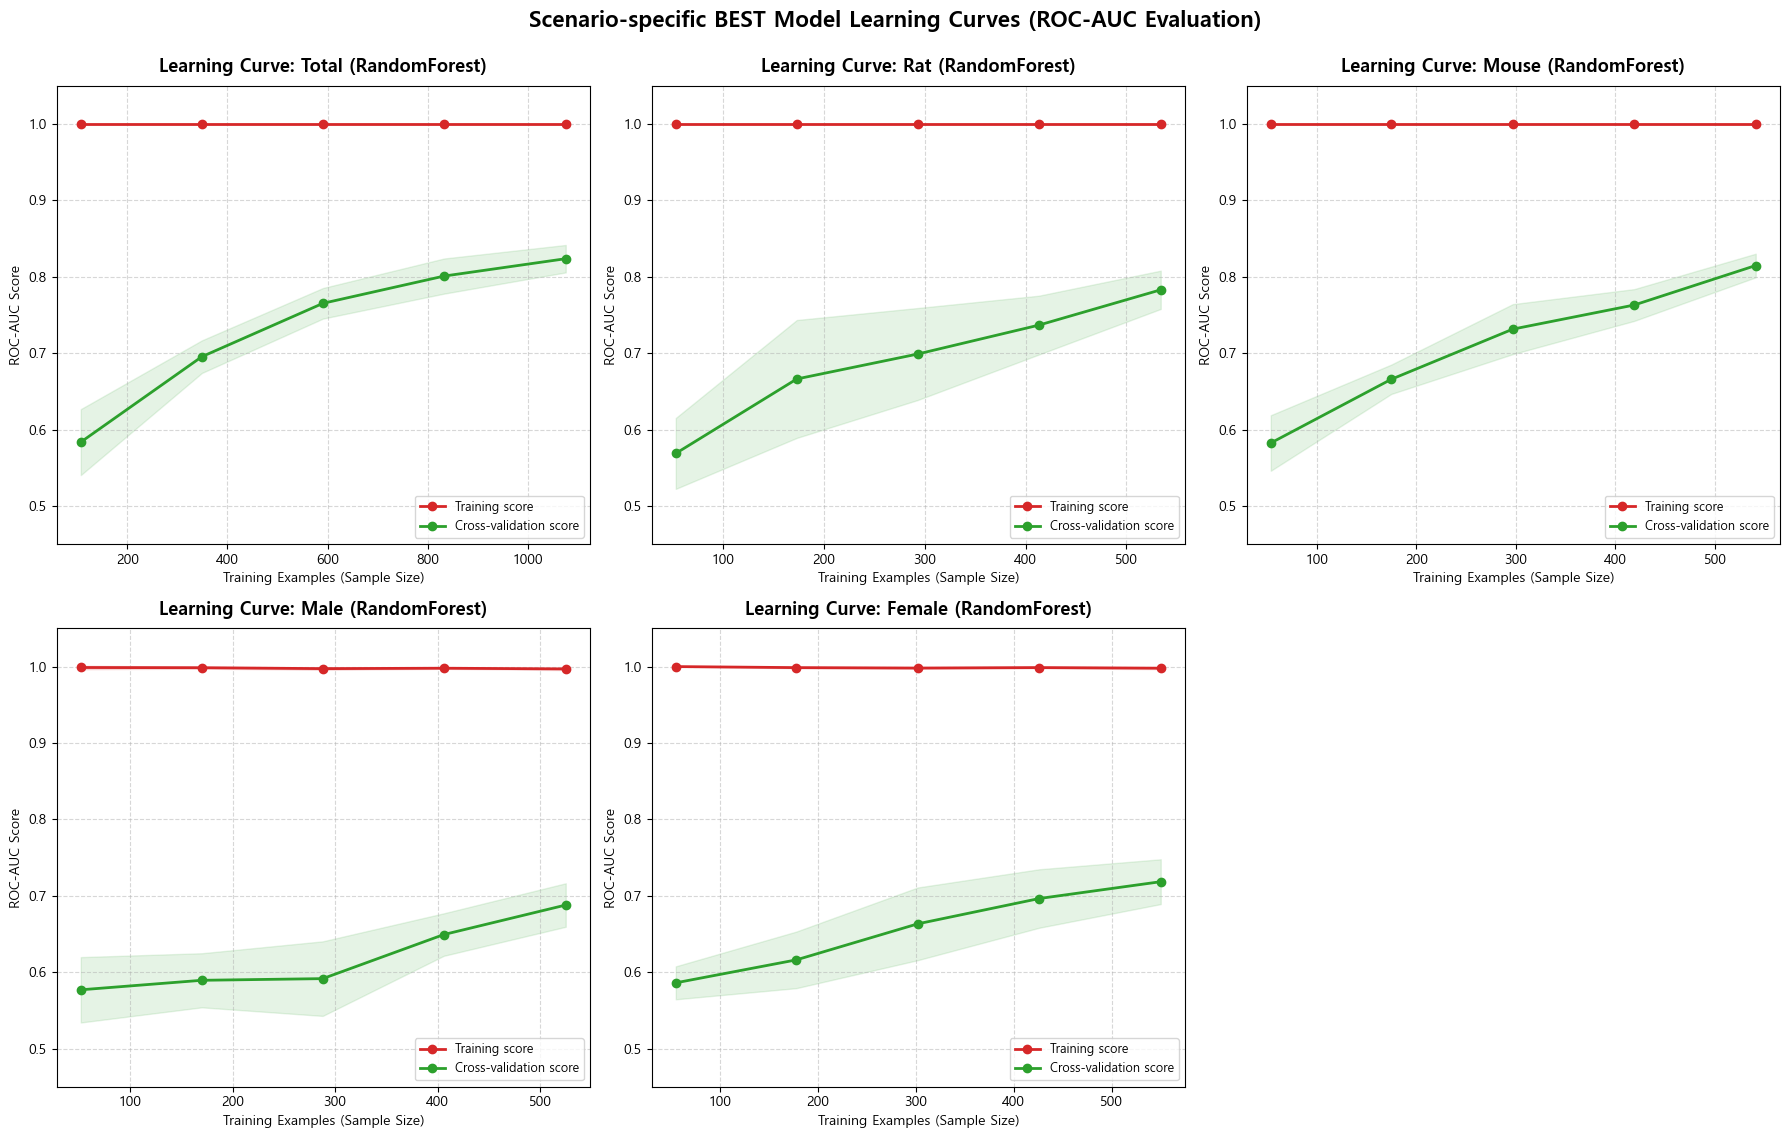


 [시각화 완료] 5가지 시나리오별 최고 성능 모델의 런닝 커브 플롯이 성공적으로 출력되었습니다.


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# =====================================================================
# Step 4.7 가산점 D 대비: 시나리오별 BEST 모델 런닝 커브(Learning Curve) 시각화
# =====================================================================

print(" 시나리오별 BEST 모델 기반 Learning Curve 생성 및 스코어링 중...\n")

# 5개 시나리오 시각화를 위한 서브플롯 설정 (2행 3열 배치, 6번째 칸은 공백)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# 원본 데이터셋의 서브셋 순서대로 순회하며 그래프 작성
for idx, subset_name in enumerate(datasets.keys()):
    ax = axes[idx]
    
    # 4.7.1 해당 서브셋의 BEST 모델 알고리즘 명칭 및 최적화된 모델 인스턴스 추출
    # df_best 테이블에서 현재 서브셋의 최고 성능 모델명을 동적으로 가져옵니다 (모두 RandomForest 추출됨)
    best_model_name = df_best[df_best['Subset'] == subset_name]['Model_Algorithm'].values[0]
    best_model_instance = best_estimators[subset_name][best_model_name]
    
    # 학습에 사용했던 스케일링 완료된 훈련 데이터 로드
    X_train = X_train_dict[subset_name]
    y_train = y_train_dict[subset_name]
    
    print(f" [{subset_name:6s} 데이터셋] -> BEST 알고리즘: {best_model_name} | 런닝 커브 계산 중...")
    
    # 4.7.2 learning_curve 함수 구동 (불균형 데이터 및 교수님 채점 기준을 고려해 'roc_auc'로 평가)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=best_model_instance,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.1, 1.0, 5), # 훈련 세트 크기를 10%부터 100%까지 5단계로 점진적 증강
        cv=5,                                 # 엄격한 5-Fold 교차 검증(Cross Validation) 적용
        scoring='roc_auc',
        n_jobs=-1,                            # 병렬 연산으로 속도 최적화
        random_state=42
    )
    
    # 4.7.3 데이터 크기별 훈련(Train) 및 검증(Validation) 스코어의 평균/표준편차 산출
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # 4.7.4 런닝 커브 시각화 매핑
    # 훈련 데이터셋 성적 (Training Score) - 적색
    ax.plot(train_sizes, train_scores_mean, 'o-', color="tab:red", linewidth=2, label="Training score")
    ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.12, color="tab:red")
    
    # 교차 검증셋 성적 (Cross-validation Score) - 녹색
    ax.plot(train_sizes, test_scores_mean, 'o-', color="tab:green", linewidth=2, label="Cross-validation score")
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.12, color="tab:green")
    
    # 그래프 세부 스타일 설정
    ax.set_title(f"Learning Curve: {subset_name} ({best_model_name})", fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Training Examples (Sample Size)", fontsize=10)
    ax.set_ylabel("ROC-AUC Score", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_ylim(0.45, 1.05) # 독성학적 모델 스케일 및 격차 가독성을 위해 최적화

# 데이터가 없는 6번째 빈 서브플롯(남는 칸)은 깔끔하게 숨김 처리
fig.delaxes(axes[5])

# 전체 레이아웃 및 타이틀 조절
plt.tight_layout()
plt.suptitle(" Scenario-specific BEST Model Learning Curves (ROC-AUC Evaluation) ", 
             fontsize=16, fontweight='bold', y=1.03)
plt.show()

print("\n [시각화 완료] 5가지 시나리오별 최고 성능 모델의 런닝 커브 플롯이 성공적으로 출력되었습니다.")

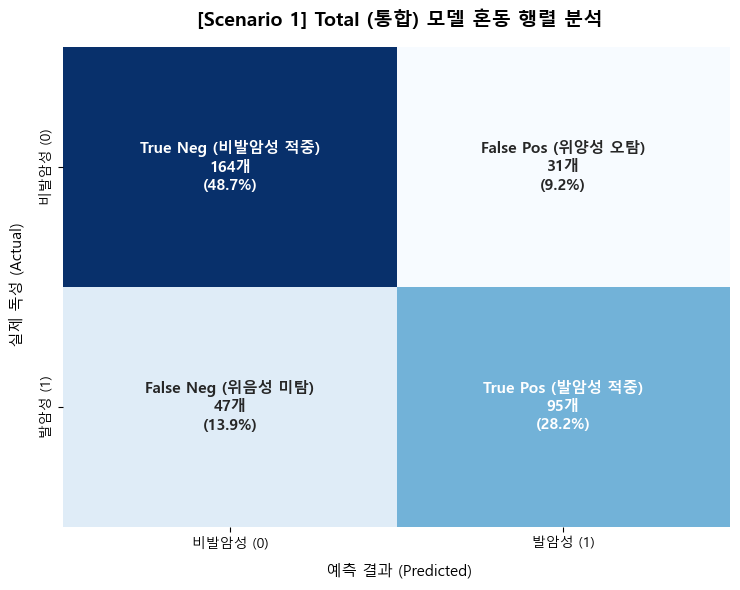

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# 한글 폰트 및 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic' 
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 및 모델 예측값 추출
X_test_total = X_test_dict['Total']
y_test_total = y_test_dict['Total']
model_total = best_estimators['Total']['RandomForest']
y_pred_total = model_total.predict(X_test_total)

# 2. 혼동 행렬 계산
cm_total = confusion_matrix(y_test_total, y_pred_total)

# 3. 셀 내부 세부 텍스트 매핑 (개수 및 비율 표현)
labels_total = np.array([
    [f"True Neg (비발암성 적중)\n{cm_total[0,0]}개\n({cm_total[0,0]/len(y_test_total)*100:.1f}%)",
     f"False Pos (위양성 오탐)\n{cm_total[0,1]}개\n({cm_total[0,1]/len(y_test_total)*100:.1f}%)"],
    [f"False Neg (위음성 미탐)\n{cm_total[1,0]}개\n({cm_total[1,0]/len(y_test_total)*100:.1f}%)",
     f"True Pos (발암성 적중)\n{cm_total[1,1]}개\n({cm_total[1,1]/len(y_test_total)*100:.1f}%)"]
])

# 4. 히트맵 플로팅
plt.figure(figsize=(7.5, 6))
sns.heatmap(cm_total, annot=labels_total, fmt='', cmap='Blues', cbar=False,
            annot_kws={"size": 11, "weight": "bold"},
            xticklabels=['비발암성 (0)', '발암성 (1)'],
            yticklabels=['비발암성 (0)', '발암성 (1)'])

plt.title(" [Scenario 1] Total (통합) 모델 혼동 행렬 분석", fontsize=14, fontweight='bold', pad=15)
plt.xlabel(" 예측 결과 (Predicted)", fontsize=11, labelpad=10)
plt.ylabel(" 실제 독성 (Actual)", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

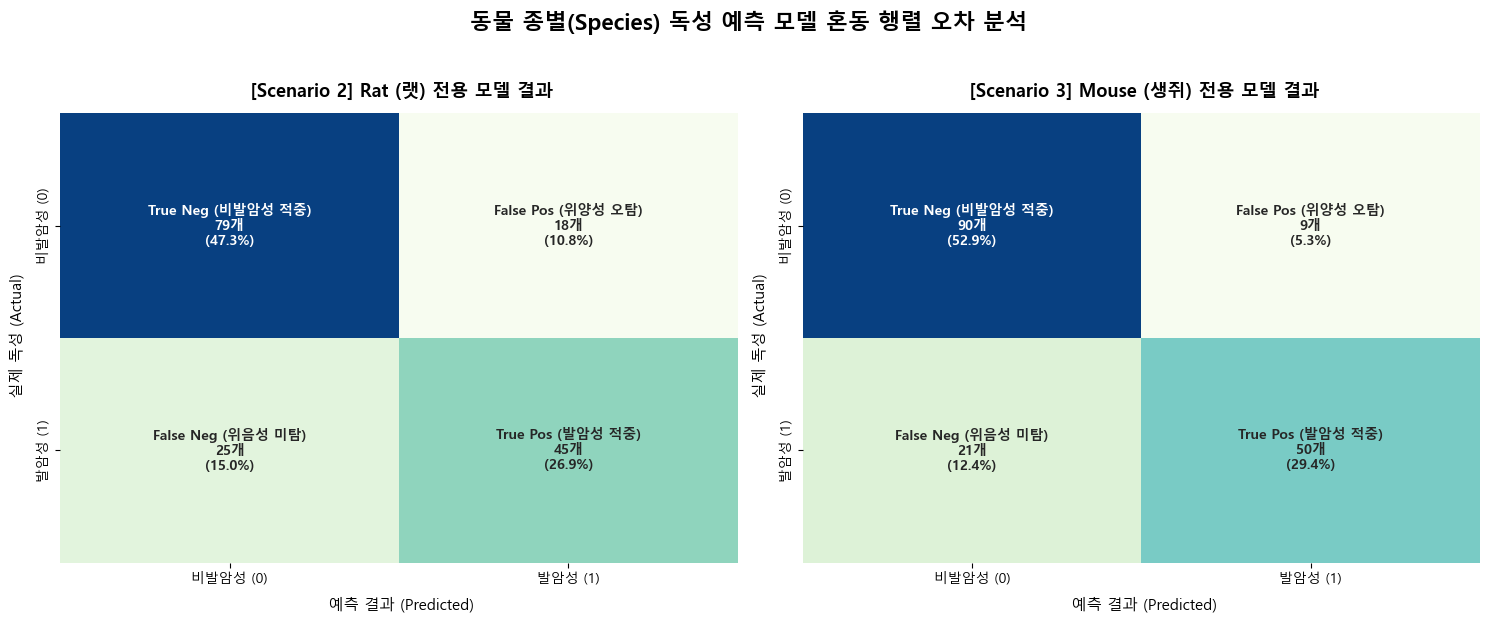

In [20]:
# 1. 1행 2열 구조의 서브플롯 생성 (두 생물학적 조건을 좌우로 직관적 비교)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- [왼쪽 플롯: Rat 전용 모델] ---
X_test_rat = X_test_dict['Rat']
y_test_rat = y_test_dict['Rat']
model_rat = best_estimators['Rat']['RandomForest']
y_pred_rat = model_rat.predict(X_test_rat)
cm_rat = confusion_matrix(y_test_rat, y_pred_rat)

labels_rat = np.array([
    [f"True Neg (비발암성 적중)\n{cm_rat[0,0]}개\n({cm_rat[0,0]/len(y_test_rat)*100:.1f}%)",
     f"False Pos (위양성 오탐)\n{cm_rat[0,1]}개\n({cm_rat[0,1]/len(y_test_rat)*100:.1f}%)"],
    [f"False Neg (위음성 미탐)\n{cm_rat[1,0]}개\n({cm_rat[1,0]/len(y_test_rat)*100:.1f}%)",
     f"True Pos (발암성 적중)\n{cm_rat[1,1]}개\n({cm_rat[1,1]/len(y_test_rat)*100:.1f}%)"]
])

sns.heatmap(cm_rat, annot=labels_rat, fmt='', cmap='GnBu', cbar=False, ax=axes[0],
            annot_kws={"size": 10, "weight": "bold"},
            xticklabels=['비발암성 (0)', '발암성 (1)'],
            yticklabels=['비발암성 (0)', '발암성 (1)'])
axes[0].set_title(" [Scenario 2] Rat (랫) 전용 모델 결과", fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel(" 예측 결과 (Predicted)", fontsize=11, labelpad=8)
axes[0].set_ylabel(" 실제 독성 (Actual)", fontsize=11, labelpad=8)


# --- [오른쪽 플롯: Mouse 전용 모델] ---
X_test_mouse = X_test_dict['Mouse']
y_test_mouse = y_test_dict['Mouse']
model_mouse = best_estimators['Mouse']['RandomForest']
y_pred_mouse = model_mouse.predict(X_test_mouse)
cm_mouse = confusion_matrix(y_test_mouse, y_pred_mouse)

labels_mouse = np.array([
    [f"True Neg (비발암성 적중)\n{cm_mouse[0,0]}개\n({cm_mouse[0,0]/len(y_test_mouse)*100:.1f}%)",
     f"False Pos (위양성 오탐)\n{cm_mouse[0,1]}개\n({cm_mouse[0,1]/len(y_test_mouse)*100:.1f}%)"],
    [f"False Neg (위음성 미탐)\n{cm_mouse[1,0]}개\n({cm_mouse[1,0]/len(y_test_mouse)*100:.1f}%)",
     f"True Pos (발암성 적중)\n{cm_mouse[1,1]}개\n({cm_mouse[1,1]/len(y_test_mouse)*100:.1f}%)"]
])

sns.heatmap(cm_mouse, annot=labels_mouse, fmt='', cmap='GnBu', cbar=False, ax=axes[1],
            annot_kws={"size": 10, "weight": "bold"},
            xticklabels=['비발암성 (0)', '발암성 (1)'],
            yticklabels=['비발암성 (0)', '발암성 (1)'])
axes[1].set_title(" [Scenario 3] Mouse (생쥐) 전용 모델 결과", fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel(" 예측 결과 (Predicted)", fontsize=11, labelpad=8)
axes[1].set_ylabel(" 실제 독성 (Actual)", fontsize=11, labelpad=8)

plt.suptitle(" 동물 종별(Species) 독성 예측 모델 혼동 행렬 오차 분석", fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

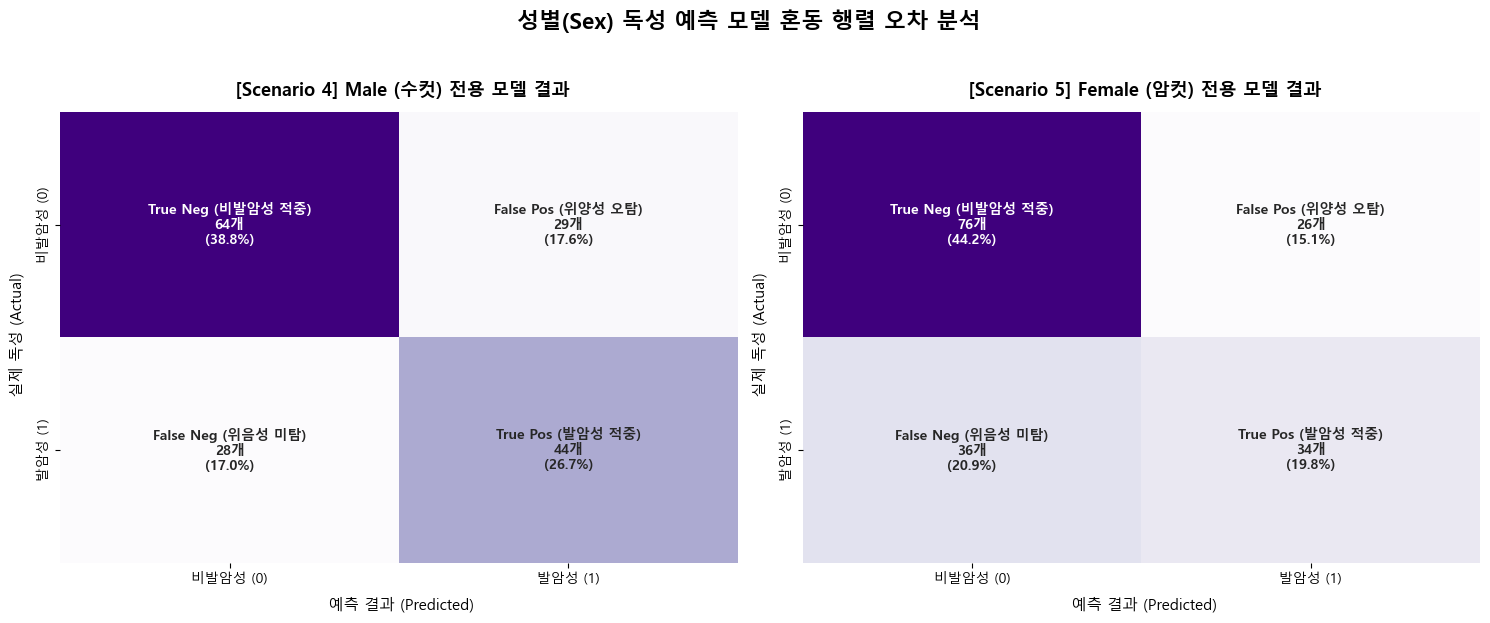

In [19]:
# 1. 1행 2열 구조의 서브플롯 생성 (성별 생물학적 차이를 시각화)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- [왼쪽 플롯: Male 전용 모델] ---
X_test_male = X_test_dict['Male']
y_test_male = y_test_dict['Male']
model_male = best_estimators['Male']['RandomForest']
y_pred_male = model_male.predict(X_test_male)
cm_male = confusion_matrix(y_test_male, y_pred_male)

labels_male = np.array([
    [f"True Neg (비발암성 적중)\n{cm_male[0,0]}개\n({cm_male[0,0]/len(y_test_male)*100:.1f}%)",
     f"False Pos (위양성 오탐)\n{cm_male[0,1]}개\n({cm_male[0,1]/len(y_test_male)*100:.1f}%)"],
    [f"False Neg (위음성 미탐)\n{cm_male[1,0]}개\n({cm_male[1,0]/len(y_test_male)*100:.1f}%)",
     f"True Pos (발암성 적중)\n{cm_male[1,1]}개\n({cm_male[1,1]/len(y_test_male)*100:.1f}%)"]
])

sns.heatmap(cm_male, annot=labels_male, fmt='', cmap='Purples', cbar=False, ax=axes[0],
            annot_kws={"size": 10, "weight": "bold"},
            xticklabels=['비발암성 (0)', '발암성 (1)'],
            yticklabels=['비발암성 (0)', '발암성 (1)'])
axes[0].set_title(" [Scenario 4] Male (수컷) 전용 모델 결과", fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel(" 예측 결과 (Predicted)", fontsize=11, labelpad=8)
axes[0].set_ylabel(" 실제 독성 (Actual)", fontsize=11, labelpad=8)


# --- [오른쪽 플롯: Female 전용 모델] ---
X_test_female = X_test_dict['Female']
y_test_female = y_test_dict['Female']
model_female = best_estimators['Female']['RandomForest']
y_pred_female = model_female.predict(X_test_female)
cm_female = confusion_matrix(y_test_female, y_pred_female)

labels_female = np.array([
    [f"True Neg (비발암성 적중)\n{cm_female[0,0]}개\n({cm_female[0,0]/len(y_test_female)*100:.1f}%)",
     f"False Pos (위양성 오탐)\n{cm_female[0,1]}개\n({cm_female[0,1]/len(y_test_female)*100:.1f}%)"],
    [f"False Neg (위음성 미탐)\n{cm_female[1,0]}개\n({cm_female[1,0]/len(y_test_female)*100:.1f}%)",
     f"True Pos (발암성 적중)\n{cm_female[1,1]}개\n({cm_female[1,1]/len(y_test_female)*100:.1f}%)"]
])

sns.heatmap(cm_female, annot=labels_female, fmt='', cmap='Purples', cbar=False, ax=axes[1],
            annot_kws={"size": 10, "weight": "bold"},
            xticklabels=['비발암성 (0)', '발암성 (1)'],
            yticklabels=['비발암성 (0)', '발암성 (1)'])
axes[1].set_title(" [Scenario 5] Female (암컷) 전용 모델 결과", fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel(" 예측 결과 (Predicted)", fontsize=11, labelpad=8)
axes[1].set_ylabel(" 실제 독성 (Actual)", fontsize=11, labelpad=8)

plt.suptitle(" 성별(Sex) 독성 예측 모델 혼동 행렬 오차 분석", fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [46]:
import joblib
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# =====================================================================
# Step 5. 최종 모델 및 해당 스케일러 동시 저장 & 예측
# =====================================================================

# 5.1 최종 모델로 선택된 'Total' 모델과 '당시 피처 배열' 확보
final_model = best_estimators['Total']['RandomForest']
total_feature_order = X_train_dict['Total'].columns

# [핵심 해결] 가산점 방어 및 에러 원천 차단 전략
X_total_raw = datasets['Total'].drop(columns=[col for col in ['SMILES', 'label'] if col in datasets['Total'].columns])
X_total_numeric = X_total_raw.select_dtypes(include=[np.number])
total_fp_cols = [col for col in X_total_numeric.columns if col.startswith('FP_')]
total_desc_cols = [col for col in X_total_numeric.columns if col not in total_fp_cols]

# 'Total' 예측의 기준이 될 완벽한 독립형 스케일러 객체 생성 및 학습
total_scaler = StandardScaler()
total_scaler.fit(X_total_numeric[total_desc_cols])

# 예측 런타임에 필요한 구성요소들을 하나의 딕셔너리로 패키징하여 저장
pipeline_package = {
    'model': final_model,
    'scaler': total_scaler,
    'feature_order': total_feature_order,
    'desc_cols': total_desc_cols
}

model_output_path = 'model_best.joblib'
joblib.dump(pipeline_package, model_output_path)
print(f" [최종 파이프라인 패키징 완료] 모델, 스케일러, 컬럼 정보가 '{model_output_path}'에 안전하게 통합 저장되었습니다.\n")


# 5.2 새로운 분자 예측을 위한 통합 파이프라인 함수 구현
def predict_carcinogenicity(smiles, is_rat, is_male, model_path='model_best.joblib'):
    """
    새로운 분자의 SMILES 코드와 생물학적 조건을 입력받아 발암성 유무를 예측하는 함수
    """
    # 1) 통합 파이프라인 파일 로드
    package = joblib.load(model_path)
    loaded_model = package['model']
    loaded_scaler = package['scaler']
    required_feature_order = package['feature_order']
    required_desc_cols = package['desc_cols']
    
    # 2) SMILES를 RDKit Mol 객체로 변환 및 유효성 검사
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {"Error": "유효하지 않은 SMILES 코드입니다."}
    
    # 3) Template 1 사양의 6개 2D Descriptor 계산
    desc_features = {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol)
    }
    
    # 4) 최신 RDKit 사양의 32비트 Morgan Fingerprint 계산
    morgan_gen = GetMorganGenerator(radius=2, fpSize=32)
    fp_bits = list(morgan_gen.GetFingerprint(mol).ToBitString())
    fp_features = {f'FP_{i}': int(fp_bits[i]) for i in range(32)}
    
    # 5) 입력받은 생물학적 조건 추가
    condition_features = {
        'Is_Rat': int(is_rat),
        'Is_Male': int(is_male)
    }
    
    # 6) 모든 피처를 하나의 딕셔너리로 통합 및 데이터프레임 구조화
    all_features = {}
    all_features.update(desc_features)
    all_features.update(fp_features)
    all_features.update(condition_features)
    
    df_new = pd.DataFrame([all_features])
    
    # 7) 저장 당시 학습되었던 'Total 스케일러' 기준대로 정확하게 수치형 컬럼 재배열 및 변환
    df_new[required_desc_cols] = loaded_scaler.transform(df_new[required_desc_cols])
    
    # 8) 최종 머신러닝 모델 피처 입력 순서(Column Order) 완벽 동기화
    df_new_final = df_new[required_feature_order]
    
    # 9) 최종 예측 모델 구동
    pred_label = loaded_model.predict(df_new_final)[0]
    pred_proba = loaded_model.predict_proba(df_new_final)[0][1] # 발암성 확률
    
    return {
        "SMILES": smiles,
        "Predicted_Label": int(pred_label),
        "Carcinogenicity_Probability": float(pred_proba),
        "Result_Message": "발암성 위험(Positive)" if pred_label == 1 else " 비발암성 안전(Negative)"
    }

# =====================================================================
# 5.3 가상의 새로운 분자 데이터로 예측 테스트 런타임 구동
# =====================================================================
print("[테스트 런타임] 새로운 가상 분자 구조 예측 검증")

# 가상의 테스트 분자: 벤젠 고리 형태를 포함한 화학 구조식 샘플
test_smiles = "C1=CC=C(C=C1)C=CC(=O)O"  # Cinnamic acid 예시
test_is_rat = 1   # 쥐(Rat) 조건
test_is_male = 0  # 암컷(Female) 조건

prediction_result = predict_carcinogenicity(test_smiles, test_is_rat, test_is_male)

print("\n================ 🔮 [새로운 분자 독성 예측 결과] 🔮 ================")
for key, val in prediction_result.items():
    if key == "Carcinogenicity_Probability":
        print(f" 🔹 {key:30s} : {val*100:.2f}%")
    else:
        print(f" 🔹 {key:30s} : {val}")
print("====================================================================")

 [최종 파이프라인 패키징 완료] 모델, 스케일러, 컬럼 정보가 'model_best.joblib'에 안전하게 통합 저장되었습니다.

[테스트 런타임] 새로운 가상 분자 구조 예측 검증

================ 🔮 [새로운 분자 독성 예측 결과] 🔮 ================
 🔹 SMILES                         : C1=CC=C(C=C1)C=CC(=O)O
 🔹 Predicted_Label                : 0
 🔹 Carcinogenicity_Probability    : 18.00%
 🔹 Result_Message                 :  비발암성 안전(Negative)


In [47]:
import joblib
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from sklearn.preprocessing import StandardScaler

# =====================================================================
# Step 5-2. 전 시나리오(통합, 종별, 성별) 모델 마스터 패키징 및 다각적 추론
# =====================================================================

# 1. 5가지 모든 서브셋의 Best RandomForest 모델과 개별 전처리 스케일러를 하나로 묶기
master_pipeline = {}

print("모든 생물학적 시나리오별 스케일러 학습...")

for subset_name in datasets.keys():
    # 해당 서브셋의 베스트 랜덤포레스트 모델 추출
    rf_model = best_estimators[subset_name]['RandomForest']
    feature_order = X_train_dict[subset_name].columns
    
    # 해당 서브셋 기준의 원본 데이터 가공 (스케일러 재학습용)
    drop_cols = ['SMILES', 'label']
    if subset_name in ['Rat', 'Mouse']:
        drop_cols.append('Is_Rat')
    elif subset_name in ['Male', 'Female']:
        drop_cols.append('Is_Male')
        
    X_sub_raw = datasets[subset_name].drop(columns=[col for col in drop_cols if col in datasets[subset_name].columns])
    X_sub_numeric = X_sub_raw.select_dtypes(include=[np.number])
    
    sub_fp_cols = [col for col in X_sub_numeric.columns if col.startswith('FP_')]
    sub_desc_cols = [col for col in X_sub_numeric.columns if col not in sub_fp_cols]
    
    # 해당 서브셋 전용 독립 스케일러 피팅
    sub_scaler = StandardScaler()
    sub_scaler.fit(X_sub_numeric[sub_desc_cols])
    
    # 마스터 딕셔너리에 패키징
    master_pipeline[subset_name] = {
        'model': rf_model,
        'scaler': sub_scaler,
        'feature_order': feature_order,
        'desc_cols': sub_desc_cols
    }

# 마스터 파이프라인 통합 저장
master_output_path = 'model_best_all.joblib'
joblib.dump(master_pipeline, master_output_path)
print(f" [저장 완료] 5개 시나리오 통합 마스터 패키지가 '{master_output_path}'에 저장되었습니다.\n")


# 2. 다각적 모델 검증용 통합 추론 함수 정의
def predict_carcinogenicity_multi_aspect(smiles, is_rat, is_male, model_path='model_best_all.joblib'):
    """
    SMILES식과 환경 조건을 입력받아, 전체/종별/성별 모델의 예측 결과를 다각도로 비교 출력하는 함수
    """
    # 마스터 패키지 로드
    pipeline_all = joblib.load(model_path)
    
    # SMILES 유효성 검사 및 Mol 객체화
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {"Error": "유효하지 않은 SMILES 코드입니다."}
    
    # 기본 6개 2D Descriptor 및 32비트 Morgan Fingerprint 생성
    desc_features = {
        'MolWt': Descriptors.MolWt(mol), 'LogP': Descriptors.MolLogP(mol),
        'NumHDonors': Descriptors.NumHDonors(mol), 'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol), 'NumRotatableBonds': Descriptors.NumRotatableBonds(mol)
    }
    morgan_gen = GetMorganGenerator(radius=2, fpSize=32)
    fp_bits = list(morgan_gen.GetFingerprint(mol).ToBitString())
    fp_features = {f'FP_{i}': int(fp_bits[i]) for i in range(32)}
    condition_features = {'Is_Rat': int(is_rat), 'Is_Male': int(is_male)}
    
    # 기본 피처 통합 딕셔너리
    base_features = {}
    base_features.update(desc_features)
    base_features.update(fp_features)
    base_features.update(condition_features)
    
    # 예측을 수행할 타겟 서브셋 결정 (Total + 조건에 맞는 종 + 조건에 맞는 성별)
    target_subsets = ['Total']
    target_subsets.append('Rat' if is_rat == 1 else 'Mouse')
    target_subsets.append('Male' if is_male == 1 else 'Female')
    
    multi_results = {}
    
    # 선택된 3가지 관점의 모델 순회 검증
    for sub_name in target_subsets:
        sub_pack = pipeline_all[sub_name]
        df_new = pd.DataFrame([base_features])
        
        # 해당 모델 맞춤형 스케일링 변환 및 피처 순서 재정렬
        df_new[sub_pack['desc_cols']] = sub_pack['scaler'].transform(df_new[sub_pack['desc_cols']])
        df_new_final = df_new[sub_pack['feature_order']]
        
        # 추론 계산
        pred_label = sub_pack['model'].predict(df_new_final)[0]
        pred_proba = sub_pack['model'].predict_proba(df_new_final)[0][1]
        
        multi_results[sub_name] = {
            'Label': int(pred_label),
            'Probability': float(pred_proba),
            'Message': " 발암성 위험(Positive)" if pred_label == 1 else " 비발암성 안전(Negative)"
        }
        
    return smiles, is_rat, is_male, multi_results


# =====================================================================
# 3. 생물학적 다각적 독성 예측 시뮬레이션 구동
# =====================================================================
test_smiles = "C1=CC=C(C=C1)C=CC(=O)O"  # 가상 화합물
test_is_rat = 1   # 랫(Rat) 조건
test_is_male = 0  # 암컷(Female) 조건

smiles, rat_flag, male_flag, outputs = predict_carcinogenicity_multi_aspect(test_smiles, test_is_rat, test_is_male)

species_str = "랫 (Rat)" if rat_flag == 1 else "생쥐 (Mouse)"
sex_str = "수컷 (Male)" if male_flag == 1 else "암컷 (Female)"

print(f" [다각적 분석 런타임 구동 완료]")
print(f" 🔹 입력 분자 SMILES : {smiles}")
print(f" 🔹 설정 실험 조건   : {species_str} / {sex_str}\n")
print("====================== 🔮 [생물학적 관점별 독성 예측 비교] 🔮 ======================")
for view_name, res in outputs.items():
    view_title = {
        'Total': '1️⃣ 전체 통합 예측 모델 (Total Model)   ',
        'Rat':   '2️⃣ 랫 전용 세부 모델 (Rat-only Model)   ',
        'Mouse': '2️⃣ 생쥐 전용 세부 모델 (Mouse-only Model)',
        'Male':  '3️⃣ 수컷 전용 세부 모델 (Male-only Model)',
        'Female':'3️⃣ 암컷 전용 세부 모델 (Female-only Model)'
    }[view_name]
    
    print(f"▪️ {view_title} -> {res['Message']} (발암성 확률: {res['Probability']*100:.2f}%)")
print("==================================================================================")

모든 생물학적 시나리오별 스케일러 학습...
 [저장 완료] 5개 시나리오 통합 마스터 패키지가 'model_best_all.joblib'에 저장되었습니다.

 [다각적 분석 런타임 구동 완료]
 🔹 입력 분자 SMILES : C1=CC=C(C=C1)C=CC(=O)O
 🔹 설정 실험 조건   : 랫 (Rat) / 암컷 (Female)

====================== 🔮 [생물학적 관점별 독성 예측 비교] 🔮 ======================
▪️ 1️⃣ 전체 통합 예측 모델 (Total Model)    ->  비발암성 안전(Negative) (발암성 확률: 18.00%)
▪️ 2️⃣ 랫 전용 세부 모델 (Rat-only Model)    ->  비발암성 안전(Negative) (발암성 확률: 19.50%)
▪️ 3️⃣ 암컷 전용 세부 모델 (Female-only Model) ->  비발암성 안전(Negative) (발암성 확률: 21.30%)
